# Tái hiện kết quả chính (Main Experiments)

Notebook này tái hiện kết quả thuật toán phân cụm NRT và NCT từ bài báo "Identifying and Clustering Counter Relationships of Team Compositions in PvP Games for Efficient Balance Analysis".
Phụ trách chính: Thành viên 2.

In [ ]:
import os
import sys
# Thêm thư mục gốc vào đường dẫn để import src
sys.path.append(os.path.abspath('..'))

import torch
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

from src.model import NRT, NCT
from src.metrics import evaluate_clustering
from src.utils import load_data, preprocess_data, extract_team_features

# Đặt random seed để đảm bảo Reproducible (theo yêu cầu TV2)
torch.manual_seed(42)
np.random.seed(42)

## 1. Chuẩn bị Dữ liệu (Real Dataset Pipeline)
Sử dụng các hàm tiền xử lý từ `src/utils.py` để tải và trích xuất dữ liệu thực từ `data/games.csv`.

In [2]:
print("Đang tải dữ liệu thực tế từ data/games.csv...")
df_raw = load_data('../data/games.csv')

if not df_raw.empty:
    df_processed = preprocess_data(df_raw)
    
    # Dữ liệu LOL có ID tướng lên đến ~516, thiết lập NUM_CHAMPIONS = 550 để làm Feature Dimension bao trùm
    NUM_CHAMPIONS = 550
    
    # Trích xuất dữ liệu thành Ma trận không gian 3 chiều [N_samples, 2_teams, NUM_CHAMPIONS]
    features = extract_team_features(df_processed, num_champions=NUM_CHAMPIONS)
    
    # Labels: 1.0 (Đội 1 thắng), 0.0 (Đội 1 thua)
    labels = np.where(df_processed['winner'].values == 1, 1.0, 0.0).astype(np.float32)
    
    print(f"Kích thước Features: {features.shape}")
    print(f"Kích thước Labels: {labels.shape}")

    features_tensor = torch.tensor(features, dtype=torch.float32)
    labels_tensor = torch.tensor(labels, dtype=torch.float32)
else:
    raise ValueError("Không tìm thấy dữ liệu! Hãy đảm bảo dataset đã được tải vào thư mục data/")

Đang tải dữ liệu thực tế từ data/games.csv...
Đã load thành công 51490 trận đấu từ ../data/games.csv
Kích thước Features: (51490, 2, 550)
Kích thước Labels: (51490,)


## 2. Phase 1: Train Neural Rating Table (NRT)
Huấn luyện mô hình NRT trên Ground Truth (Win/Loss) để học Rating tự nhiên của các tướng trong đội hình, thông qua Bradley-Terry Model: $P_{expected} = \frac{R(A)}{R(A)+R(B)}$.

In [3]:
nrt_model = NRT(input_dim=NUM_CHAMPIONS)
nrt_optimizer = optim.Adam(nrt_model.parameters(), lr=0.001)
nrt_epochs = 30

dataset = TensorDataset(features_tensor, labels_tensor)
dataloader = DataLoader(dataset, batch_size=256, shuffle=True)

print("--- BẮT ĐẦU TRAINING NRT ---")
nrt_model.train()
for epoch in range(nrt_epochs):
    total_loss = 0
    for batch_X, batch_y in dataloader:
        nrt_optimizer.zero_grad()
        
        comp_A = batch_X[:, 0, :]
        comp_B = batch_X[:, 1, :]
        
        expected_win_A, _, _ = nrt_model(comp_A, comp_B)
        
        # NRT MSE Loss giữa Bradley-Terry prob và Actual Win/Loss
        loss = F.mse_loss(expected_win_A.squeeze(), batch_y)
        loss.backward()
        nrt_optimizer.step()
        
        total_loss += loss.item()
        
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{nrt_epochs} - Loss NRT: {total_loss/len(dataloader):.4f}")

--- BẮT ĐẦU TRAINING NRT ---
Epoch 10/30 - Loss NRT: 0.1960
Epoch 20/30 - Loss NRT: 0.1085
Epoch 30/30 - Loss NRT: 0.0668


## 3. Tạo Target Residual ($W_{res}$)
Mối quan hệ khắc chế $W_{res}$ chính là hiệu số: Thực tế (Actual Win/Loss) trừ đi Dự báo sức mạnh (Expected). Càng lệch nhiều tức là khắc chế (hoặc bị khắc chế) càng mạnh.

In [4]:
nrt_model.eval()
with torch.no_grad():
    comp_A = features_tensor[:, 0, :]
    comp_B = features_tensor[:, 1, :]
    expected_win_A, _, _ = nrt_model(comp_A, comp_B)
    
    # Theo Công thức (7) trong bài báo
    residual_target = labels_tensor.unsqueeze(1) - expected_win_A

print(f"Kích thước Residual Target: {residual_target.shape}")
print(f"Vài mẫu W_res đầu tiên:\n{residual_target[:5].numpy()}")

Kích thước Residual Target: torch.Size([51490, 1])
Vài mẫu W_res đầu tiên:
[[3.4570694e-06]
 [3.1490028e-02]
 [1.1756778e-02]
 [2.3841858e-07]
 [1.9681406e-01]]


## 4. Phase 2: Train Neural Counter Table (NCT) & Phân cụm (VQ)
Huấn luyện Siamese NCT mục tiêu dự đoán đúng phần dư $W_{res}$ qua không gian Vector Quantization rời rạc. VQ Loss sẽ ép các đội hình tương đồng về cùng một Codebook (Cụm).

In [5]:
M_CLUSTERS = 9 # Thử nghiệm 9 cụm đội hình
nct_model = NCT(input_dim=NUM_CHAMPIONS, num_embeddings=M_CLUSTERS, embedding_dim=64)
nct_optimizer = optim.Adam(nct_model.parameters(), lr=0.0005)
nct_epochs = 40

# Batch_y bây giờ là residual_target!
nct_dataset = TensorDataset(features_tensor, residual_target)
nct_dataloader = DataLoader(nct_dataset, batch_size=256, shuffle=True)

print("\n--- BẮT ĐẦU TRAINING NCT ---")
nct_model.train()
for epoch in range(nct_epochs):
    total_loss = 0
    for batch_X, batch_res in nct_dataloader:
        nct_optimizer.zero_grad()
        
        comp_A = batch_X[:, 0, :]
        comp_B = batch_X[:, 1, :]
        
        residual_pred, loss_vq, loss_mean, _, _ = nct_model(comp_A, comp_B)
        
        # Suy hao tái chiết
        loss_res = F.mse_loss(residual_pred, batch_res)
        
        beta_N = nct_model.vq.beta_N
        beta_M = nct_model.vq.beta_M
        # Suy hao toàn cục cho lượng tử hóa có chuẩn hoá Mean
        loss = loss_res + beta_N * loss_vq + beta_M * loss_mean
        
        loss.backward()
        nct_optimizer.step()
        
        total_loss += loss.item()
        
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{nct_epochs} - Total NCT Loss: {total_loss/len(nct_dataloader):.4f}")


--- BẮT ĐẦU TRAINING NCT ---
Epoch 10/40 - Total NCT Loss: 0.1123
Epoch 20/40 - Total NCT Loss: 0.6401
Epoch 30/40 - Total NCT Loss: 1.1318
Epoch 40/40 - Total NCT Loss: 0.1860


## 5. Đánh giá chất lượng Phân cụm (Clustering Metrics)
Trích xuất trực tiếp đặc trưng ẩn ($z_e$) và nhãn các cụm (Codebook Index) để tính Metrics.

In [6]:
nct_model.eval()
with torch.no_grad():
    # Ta chỉ quan tâm đội phân tích như là tập data chuẩn
    z_e_A = nct_model.encoder(features_tensor[:, 0, :])
    _, _, _, cluster_labels = nct_model.vq(z_e_A)
    
    latent_features = z_e_A.cpu().numpy()
    labels_np = cluster_labels.cpu().numpy().flatten()
    
    # Đánh giá chỉ số
    metrics = evaluate_clustering(latent_features, labels_np)

print("=== KẾT QUẢ ĐÁNH GIÁ CHẤT LƯỢNG PHÂN CỤM ===")
for k, v in metrics.items():
    print(f"* {k}: {v:.4f}")

=== KẾT QUẢ ĐÁNH GIÁ CHẤT LƯỢNG PHÂN CỤM ===
* Silhouette: 0.0951
* Davies-Bouldin: 1.5539
* Calinski-Harabasz: 5283.9858


## 6. Trực quan hóa (t-SNE Latent Space)
Plotting các điểm phân bố vào không gian t-SNE để hiển thị các cụm tường minh đã học được. Mỗi màu thể hiện một trường phái đội hình (Cluster).

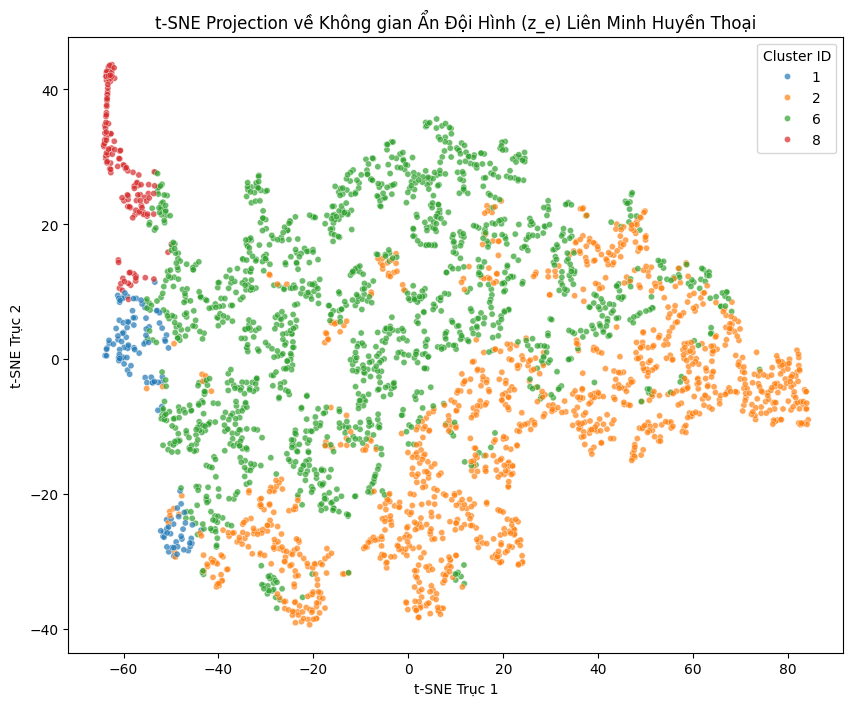

In [7]:
# Lấy ngẫu nhiên vài nghìn điểm để plot đẹp nhất
sample_size = 3000

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(latent_features[:sample_size])
y_tsne = labels_np[:sample_size]

plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=y_tsne, palette="tab10", s=20, alpha=0.7)
plt.title("t-SNE Projection về Không gian Ẩn Đội Hình (z_e) Liên Minh Huyền Thoại")
plt.xlabel("t-SNE Trục 1")
plt.ylabel("t-SNE Trục 2")
plt.legend(title="Cluster ID")
plt.show()